# Operator-resolved transport

For a BdG (Nambu) junction, `.didv(energy, component=...)` decomposes the total conductance into
its normal (electron-transmission) and Andreev-reflection contributions --
`component="electron"`/`component="Andreev"` project the scattering process onto the
electron/hole Nambu sectors before evaluating the conductance, rather than tracing over the full
Nambu space at once. Below, a normal/superconductor junction's total conductance is split into
these two operator-resolved components, showing how sub-gap transport is carried entirely by
Andreev reflection while above-gap transport is dominated by ordinary electron transmission.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

../../../src/pyqula/transporttk/smatrix.py:46: UserWarning: the lead selfenergies could not be resolved at delta=1e-12 at energy -0.01, so the S-matrix was evaluated at delta=1e-10 instead (the junction's own delta is 0.0001). The Fisher-Lee S-matrix is only unitary in the limit of small lead broadening, so this result is correspondingly less unitary; the unitarity check is loosened to match.
  warnings.warn("the lead selfenergies could not be resolved at "


../../../src/pyqula/transporttk/smatrix.py:46: UserWarning: the lead selfenergies could not be resolved at delta=1e-12 at energy 0.01, so the S-matrix was evaluated at delta=1e-10 instead (the junction's own delta is 0.0001). The Fisher-Lee S-matrix is only unitary in the limit of small lead broadening, so this result is correspondingly less unitary; the unitarity check is loosened to match.
  warnings.warn("the lead selfenergies could not be resolved at "


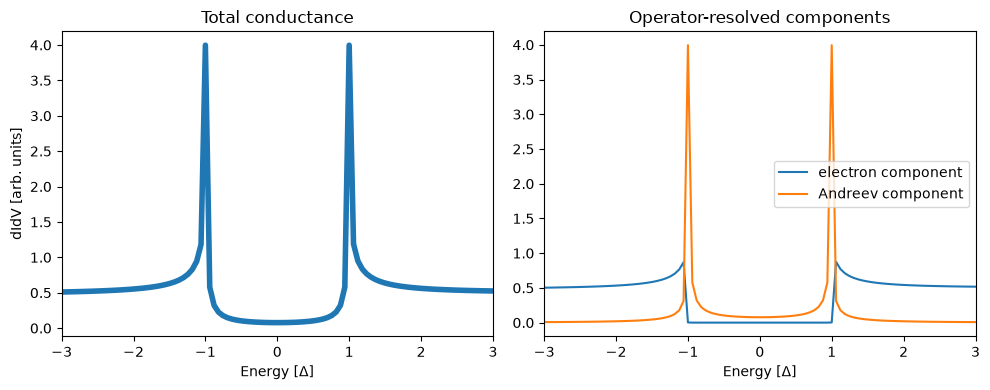

In [2]:
g = geometry.chain()
h = g.get_hamiltonian()
h.add_onsite(1.0)
h1 = h.copy() # normal lead
h2 = h.copy() # superconducting lead
delta = 0.01
h2.add_swave(delta)
HT = heterostructures.build(h1,h2)
T = 0.3
HT.set_coupling(T)
es = np.linspace(-.03,.03,100)

G  = [HT.didv(energy=e) for e in es]
Ge = [HT.didv(energy=e,component="electron") for e in es]
Gh = [HT.didv(energy=e,component="Andreev") for e in es]

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(es/delta,G,linewidth=4)
axs[0].set_title("Total conductance") ; axs[0].set_xlabel(r"Energy [$\Delta$]")
axs[0].set_ylabel("dIdV [arb. units]") ; axs[0].set_xlim([-3,3])
axs[1].plot(es/delta,Ge,label="electron component")
axs[1].plot(es/delta,Gh,label="Andreev component")
axs[1].set_title("Operator-resolved components") ; axs[1].set_xlabel(r"Energy [$\Delta$]")
axs[1].legend() ; axs[1].set_xlim([-3,3])
plt.tight_layout()
plt.show()

Sweeping the transparency $T$ as well, the two components become maps over the energy and $T$.

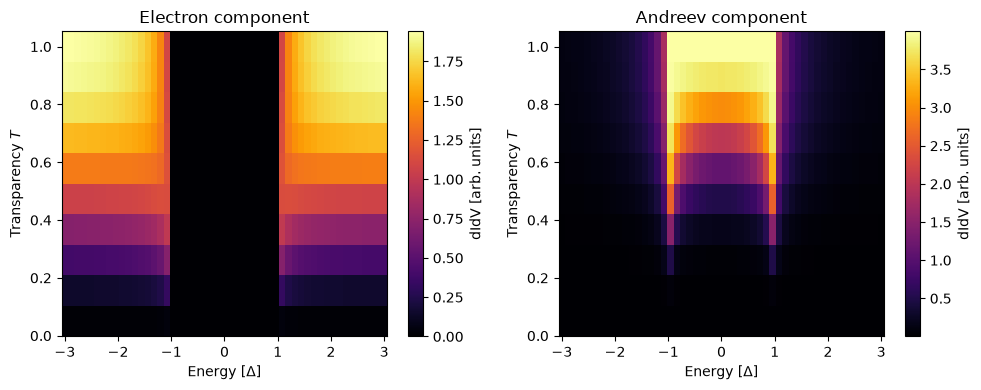

In [3]:
Ts = np.linspace(0.05,1.0,10) # interface transparencies
es_map = np.linspace(-.03,.03,51)
Gemap,Ghmap = [],[]
for T in Ts:
    HT = heterostructures.build(h1,h2)
    HT.set_coupling(T)
    Gemap.append([HT.didv(energy=e,component="electron") for e in es_map])
    Ghmap.append([HT.didv(energy=e,component="Andreev") for e in es_map])

fig,axs = plt.subplots(1,2,figsize=(10,4))
for ax,Gmap,title in zip(axs,[Gemap,Ghmap],["Electron component","Andreev component"]):
    im = ax.pcolormesh(es_map/delta,Ts,np.array(Gmap),shading="auto",cmap="inferno")
    fig.colorbar(im,ax=ax,label="dIdV [arb. units]")
    ax.set_title(title) ; ax.set_xlabel(r"Energy [$\Delta$]") ; ax.set_ylabel("Transparency $T$")
plt.tight_layout()
plt.show()